In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
len(words)

32033

In [3]:
# build the vocabulary of chars and mappings
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


## Compile the dataset for the NN

**Block size:** Context length. How many chars do we take to predict the next one?

In [60]:
block_size = 3
X, Y = [], []
for w in words:
    # print(w)
    context = [0] * block_size
    for ch in w + '.': 
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)
X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

## Lookup table

Build a lookup table C that will store the embeddings for each of the words.

We have 27 possible chars and we'll embed them in a lower-dimensional space.

In [61]:
C = torch.randn((27, 2))

emb = C[X] # pytorch indexing --> builds a [N; block_size; # dimensions in embedding vectors] tensor
emb.shape

torch.Size([228146, 3, 2])

## Building the hidden layer

In [62]:
# 6 inputs, 100 neurons
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

W1.shape

torch.Size([6, 100])

What we want to do next: `emb @ W1 + b1`

**Problem:** `emb.shape = [32, 3, 2]` and `W1.shape = [6, 100]`

We need to reduce the dimensions of the embedding tensor to be able to multiply with the weights and sum the biases.  

In [63]:
# Concatenate the inputs by using the 'view' operation

# Using the -1 makes pytorch infer the size
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
h.shape # The result is the 100-dimensional activations for each of the N (32 here) examples

# Side note: using 'view' is the most efficient way to perform the operations, as it doesn't create new memory. 

torch.Size([228146, 100])

## Building the output layer

In [17]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

logits = h @ W2 + b2
logits.shape

torch.Size([32, 27])

In [20]:
counts = logits.exp()
probs = counts / counts.sum(1, keepdims=True)

# Verify the prob distribution for any row
probs[5].sum()

torch.float32

### Get a first look on how the NN is

Get the probability assigned to the char that actually follows the sequence, given by the labels tensor Y.

In [22]:
probs[torch.arange(32), Y]

tensor([1.5879e-07, 1.3684e-05, 6.6786e-06, 2.3844e-09, 2.6182e-16, 3.2599e-05,
        7.9271e-01, 1.4192e-12, 8.9569e-09, 3.0179e-15, 1.7141e-13, 4.1616e-09,
        3.0984e-07, 1.2822e-03, 1.2306e-06, 1.9548e-14, 5.0665e-14, 2.4899e-02,
        7.9316e-04, 6.5729e-09, 1.1172e-03, 9.6671e-01, 4.7747e-06, 9.0028e-05,
        3.6723e-02, 5.8740e-02, 1.8478e-07, 3.0177e-04, 8.2040e-09, 5.2048e-06,
        4.1527e-07, 8.2022e-02])

Some are very good predictions (7.9271e-01 --> 0.79), and some are very bad predictions (2.6182e-16)

This is because **the NN is not trained**. 

## Calculate the loss

In [24]:
loss = -probs[torch.arange(32), Y].log().mean()
loss

tensor(14.5700)

The current loss, with an untrained network, has a value of 14.57

We want to **minimize that loss**.

## Rearrange all values

In [138]:
# Define all parameters
g = torch.Generator().manual_seed(2147483647) # Reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [139]:
# Total amount of parameters to tune
sum(p.nelement() for p in parameters)

3481

## Set up training

Using `F.cross_entropy()` instead of manually calculating the loss:
- More efficient forward and backward passes
- Doesn't create additional intermediate tensors
- Supports getting extreme values for logits (unusual, but could happen getting a value of 100 --> 100.exp() returns inf)

In [140]:
# Initial setup
for p in parameters: 
    p.requires_grad = True

## Finding the right learning rate

This should be ran once and reset parameters before and after.

In [136]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

lri, lossi = [], []
##########################################
# HYPERPARAMETERS
num_iterations = 1000
batch_size = 32

for i in range(num_iterations): 
    
    # mini-batch
    ix = torch.randint(0, X.shape[0], (batch_size,))
    
    # forward pass
    emb = C[X[ix]] # (32, 3, 2) 
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix]) # More efficient implementation
    # print(loss.item())
    
    # backward pass
    for p in parameters: 
        p.grad = None
    loss.backward()

    # udpate
    lr = lrs[i]
    for p in parameters:
        p.data -= lr * p.grad

    # track stats
    lri.append(lre[i])
    lossi.append(loss.item())

print(loss.item())

10.041041374206543


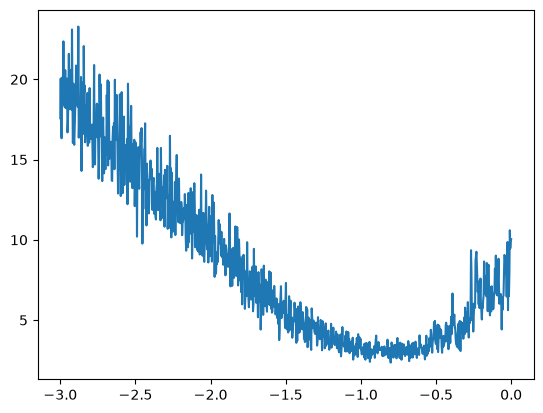

In [137]:
# Plot how the loss behaves with the different learning rates
plt.plot(lri, lossi)

The X-axis contains the exponents for the learning rate.

**Conclusion:** Values between 10^(-1) and 10^(-0.5) are good learning rates. 

In [67]:
# HYPERPARAMETERS
learning_rate = 0.1
num_iterations = 100000

for _ in range(num_iterations): 
    
    # forward pass
    emb = C[X] # (32, 3, 2) 
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y) # More efficient implementation
    print(loss.item())
    
    # backward pass
    for p in parameters: 
        p.grad = None
    
    loss.backward()
    
    for p in parameters:
        p.data -= learning_rate * p.grad  

# print(loss.item())

19.505229949951172
18.021991729736328
17.105224609375
16.40226936340332
15.836977005004883
15.327887535095215
14.85720443725586
14.41867733001709
14.007678985595703
13.620527267456055


## Mini-batching

Each iteration takes fairly long, since it has to perform calculations on ~228,000 values twice. 

A good solution is to take **batches** from the dataset and work on those. Allows much faster iteration and decreasing of the loss. 

However, it **lowers the quality of the gradient**, and its direction is not as reliable as when using all the available values. 
- This explains why, between consecutive iterations, the loss may increase. 

In [146]:
# HYPERPARAMETERS
learning_rate = 0.1
num_iterations = 10000
batch_size = 32

for _ in range(num_iterations): 
    
    # mini-batch
    ix = torch.randint(0, X.shape[0], (batch_size,))
    
    # forward pass
    emb = C[X[ix]] # (32, 3, 2) 
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix]) # More efficient implementation
    # print(loss.item())
    
    # backward pass
    for p in parameters: 
        p.grad = None
    
    loss.backward()
    
    for p in parameters:
        p.data -= learning_rate * p.grad  

print(loss.item())

1.8723112344741821


In [147]:
# evaluate the loss for all examples
emb = C[X] 
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y) 
loss

tensor(2.3192, grad_fn=<NllLossBackward0>)